In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

plt.style.use('seaborn-v0_8-darkgrid')
save_dir = "/content/drive/MyDrive/hadoop_openstack"
os.makedirs(save_dir, exist_ok=True)

print("Libraries ready! ✅")

# Hadoop Results
hadoop_results = {
    "Random Forest":    {"ROC_AUC": 1.0000, "Recall": 1.00, "F1": 1.00, "Precision": 1.00, "Type": "ML Supervised"},
    "CNN Classifier":   {"ROC_AUC": 0.9617, "Recall": 0.84, "F1": 0.91, "Precision": 1.00, "Type": "DL Supervised"},
    "LSTM Autoencoder": {"ROC_AUC": 0.6519, "Recall": 0.29, "F1": 0.45, "Precision": 0.99, "Type": "DL Unsupervised"},
    "GAN":              {"ROC_AUC": 0.6133, "Recall": 0.01, "F1": 0.03, "Precision": 0.81, "Type": "Generative"},
    "VAE":              {"ROC_AUC": 0.5235, "Recall": 0.07, "F1": 0.12, "Precision": 0.95, "Type": "Generative"},
    "One-Class SVM":    {"ROC_AUC": 0.2383, "Recall": 0.20, "F1": 0.32, "Precision": 0.03, "Type": "ML Unsupervised"},
    "Isolation Forest": {"ROC_AUC": 0.2092, "Recall": 0.46, "F1": 0.60, "Precision": 0.87, "Type": "ML Unsupervised"},
}

# Spark Results
spark_results = {
    "CNN Classifier":   {"ROC_AUC": 0.9978, "Recall": 1.00, "F1": 0.16, "Type": "DL Supervised"},
    "Random Forest":    {"ROC_AUC": 0.9902, "Recall": 0.89, "F1": 0.44, "Type": "ML Supervised"},
    "LSTM Autoencoder": {"ROC_AUC": 0.9822, "Recall": 0.93, "F1": 0.05, "Type": "DL Unsupervised"},
    "Isolation Forest": {"ROC_AUC": 0.9559, "Recall": 0.04, "F1": 0.04, "Type": "ML Unsupervised"},
    "VAE":              {"ROC_AUC": 0.7700, "Recall": 0.16, "F1": 0.01, "Type": "Generative"},
    "GAN":              {"ROC_AUC": 0.2479, "Recall": 0.12, "F1": 0.01, "Type": "Generative"},
    "One-Class SVM":    {"ROC_AUC": 0.2388, "Recall": 0.01, "F1": 0.00, "Type": "ML Unsupervised"},
}

df_hadoop = pd.DataFrame(hadoop_results).T.sort_values('ROC_AUC', ascending=False)
df_spark = pd.DataFrame(spark_results).T.sort_values('ROC_AUC', ascending=False)

print("\nHadoop Results:")
print(df_hadoop[['ROC_AUC', 'Recall', 'F1', 'Type']])
print("\nSpark Results:")
print(df_spark[['ROC_AUC', 'Recall', 'F1', 'Type']])

Mounted at /content/drive
Libraries ready! ✅

Hadoop Results:
                 ROC_AUC Recall    F1             Type
Random Forest        1.0    1.0   1.0    ML Supervised
CNN Classifier    0.9617   0.84  0.91    DL Supervised
LSTM Autoencoder  0.6519   0.29  0.45  DL Unsupervised
GAN               0.6133   0.01  0.03       Generative
VAE               0.5235   0.07  0.12       Generative
One-Class SVM     0.2383    0.2  0.32  ML Unsupervised
Isolation Forest  0.2092   0.46   0.6  ML Unsupervised

Spark Results:
                 ROC_AUC Recall    F1             Type
CNN Classifier    0.9978    1.0  0.16    DL Supervised
Random Forest     0.9902   0.89  0.44    ML Supervised
LSTM Autoencoder  0.9822   0.93  0.05  DL Unsupervised
Isolation Forest  0.9559   0.04  0.04  ML Unsupervised
VAE                 0.77   0.16  0.01       Generative
GAN               0.2479   0.12  0.01       Generative
One-Class SVM     0.2388   0.01   0.0  ML Unsupervised


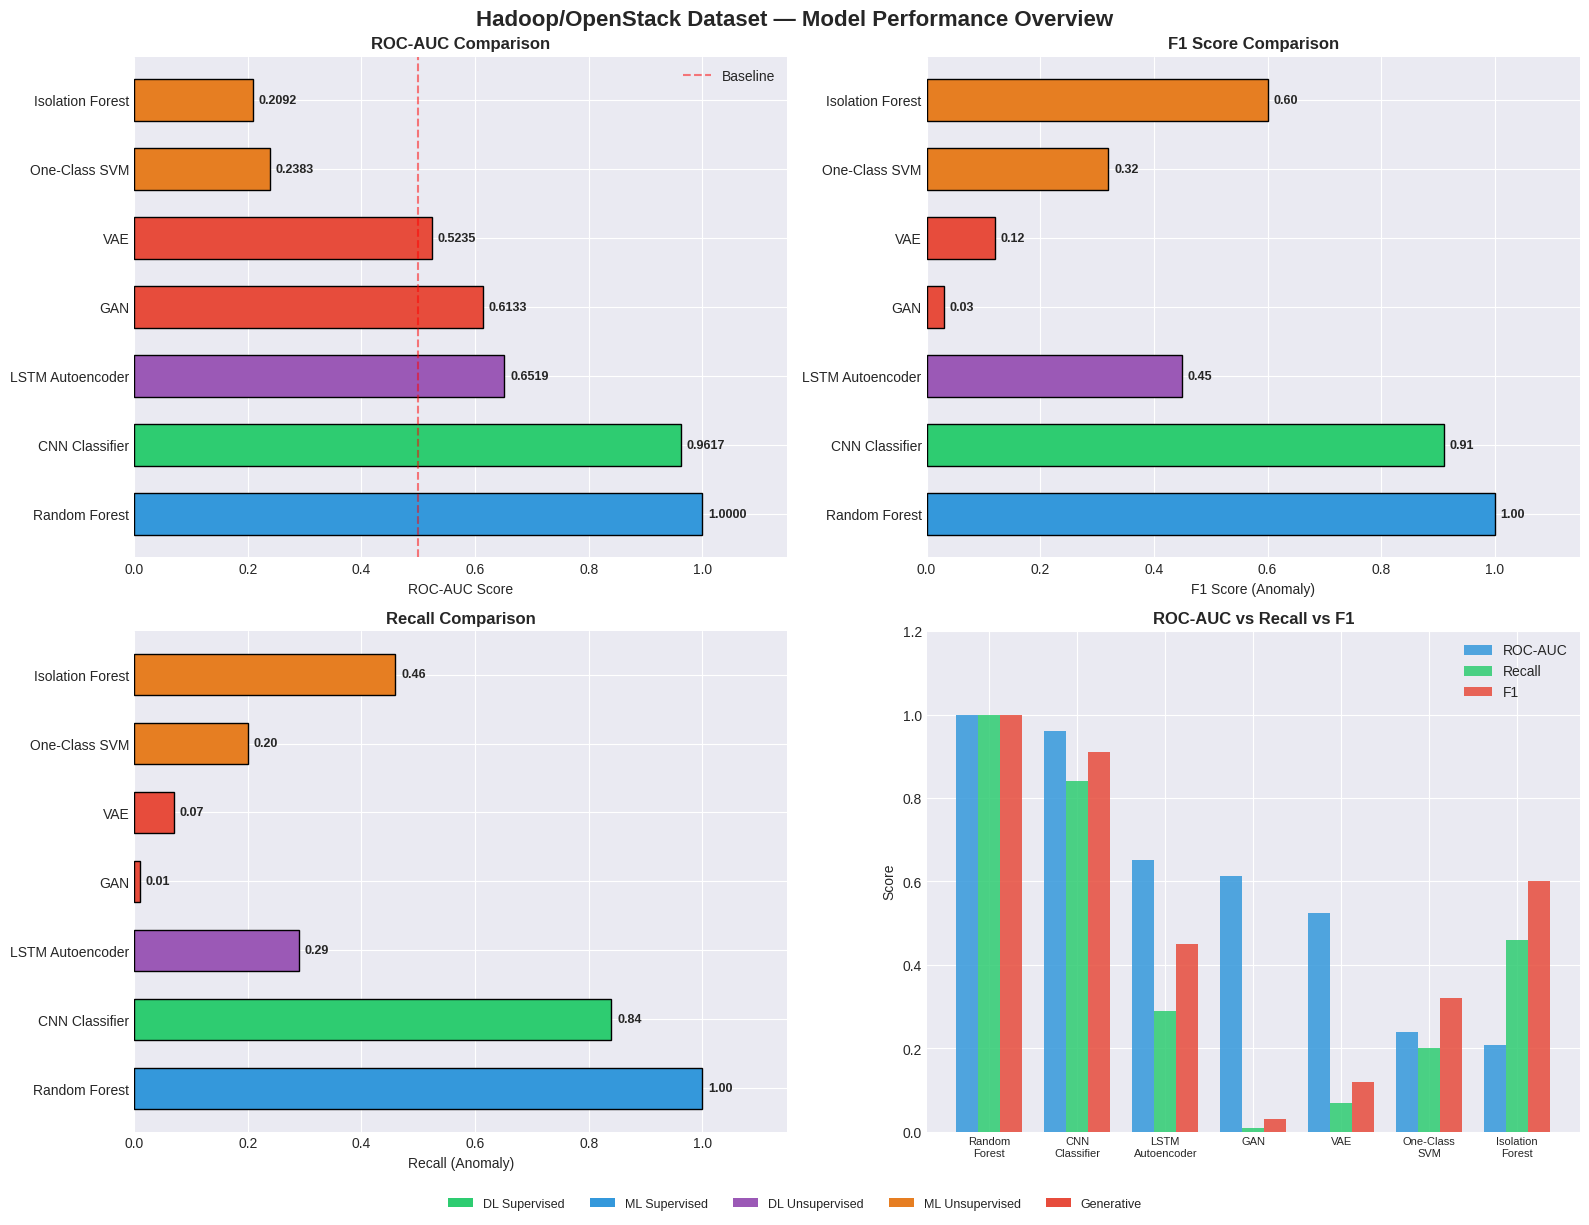

Figure 1 saved! ✅


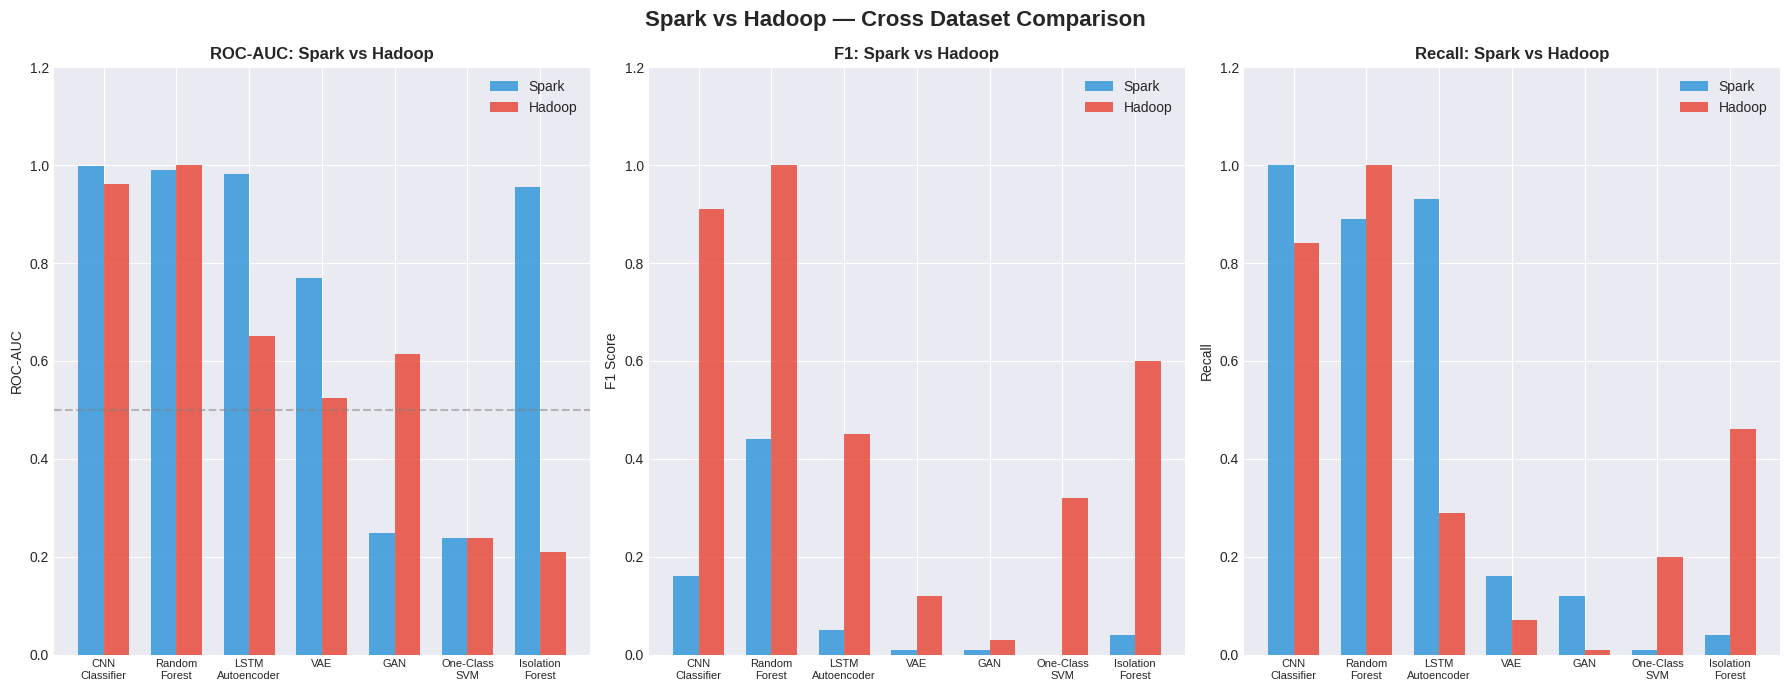

Figure 2 saved! ✅


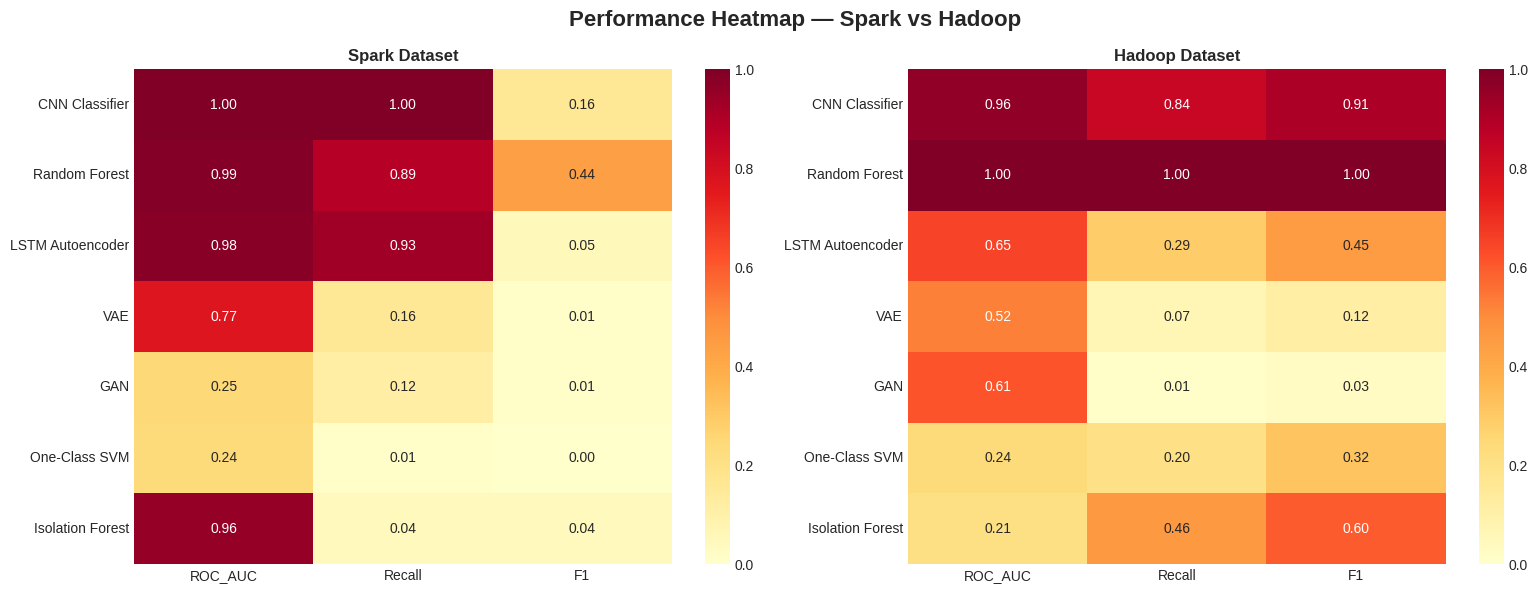

Figure 3 saved! ✅


/tmp/ipykernel_1566/1939247615.py:186: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace(' ', '\n') for c in categories], fontsize=9)
/tmp/ipykernel_1566/1939247615.py:186: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace(' ', '\n') for c in categories], fontsize=9)


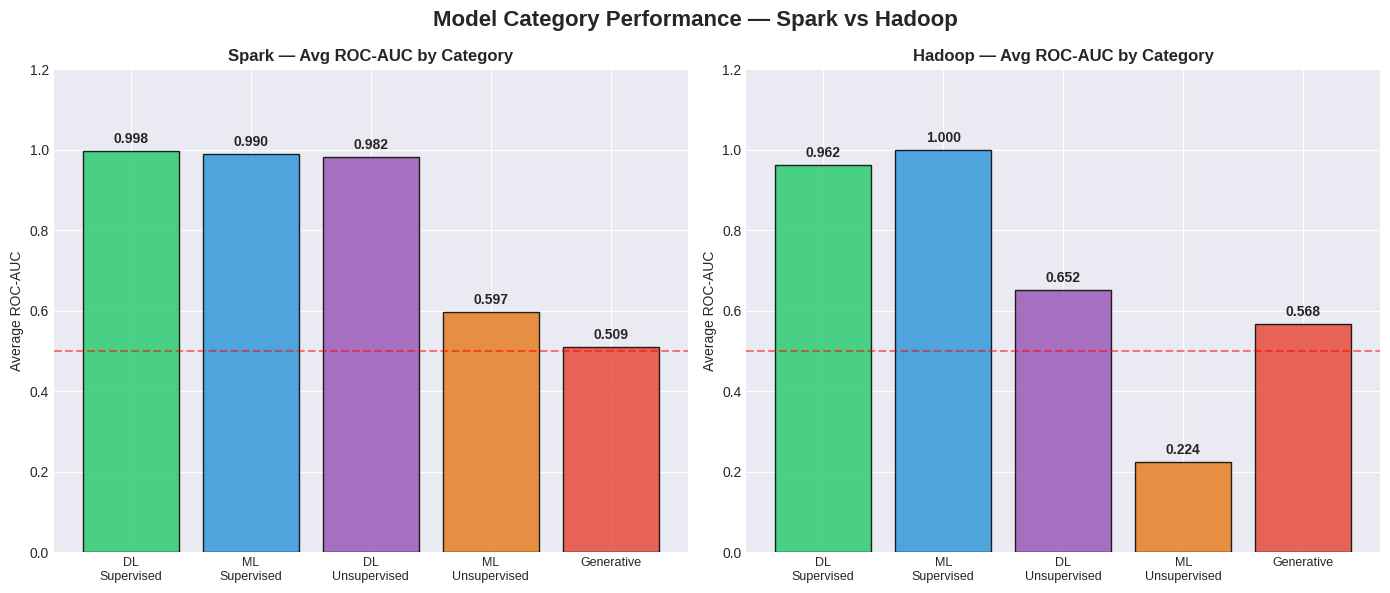

Figure 4 saved! ✅


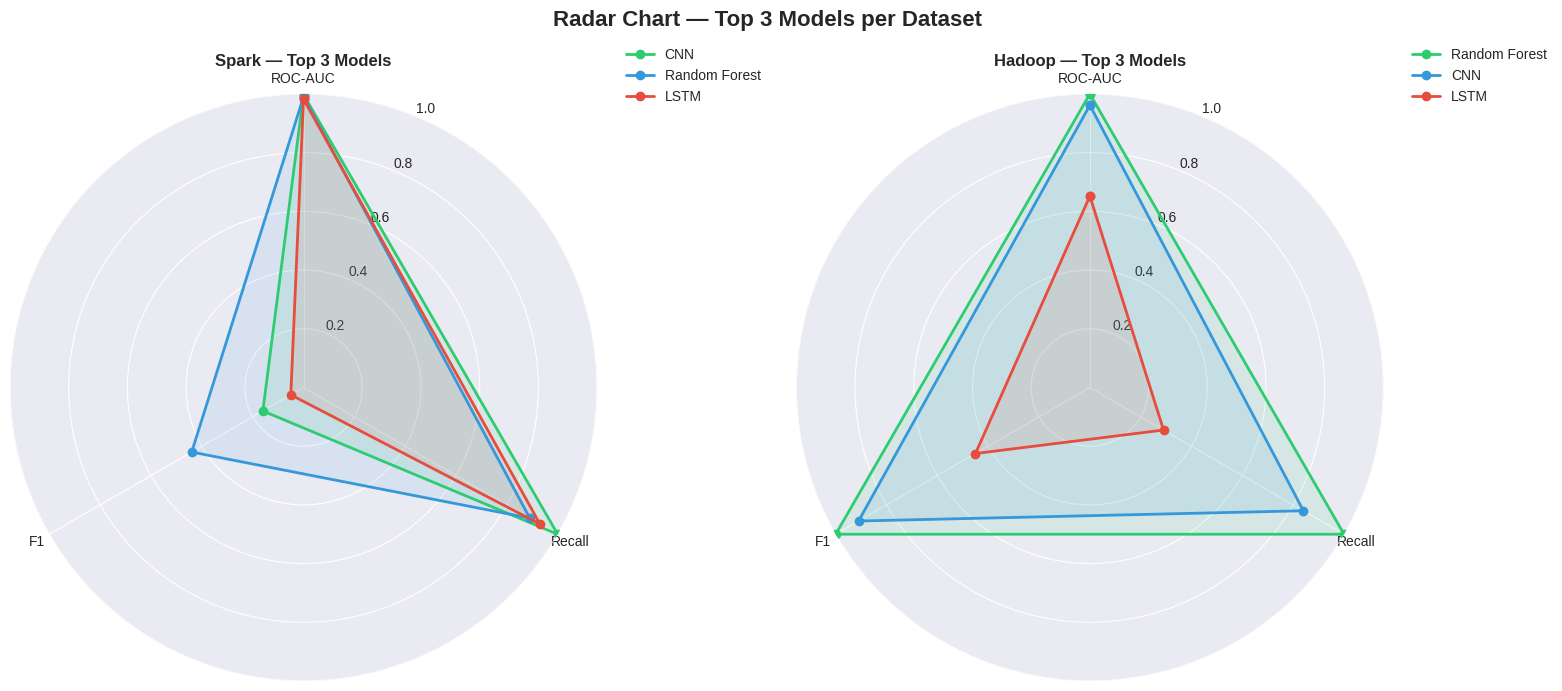

Figure 5 saved! ✅

Saare graphs save ho gaye! ✅
Location: /content/drive/MyDrive/hadoop_openstack


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

color_map = {
    'DL Supervised':    '#2ecc71',
    'ML Supervised':    '#3498db',
    'DL Unsupervised':  '#9b59b6',
    'ML Unsupervised':  '#e67e22',
    'Generative':       '#e74c3c'
}

models = list(hadoop_results.keys())
types = [hadoop_results[m]['Type'] for m in models]
colors = [color_map[t] for t in types]

# ============================================
# FIGURE 1: Hadoop Complete Overview (2x2)
# ============================================
fig1, axes = plt.subplots(2, 2, figsize=(16, 12))
fig1.suptitle("Hadoop/OpenStack Dataset — Model Performance Overview",
              fontsize=16, fontweight='bold')

# Plot 1: ROC-AUC Bar
ax1 = axes[0, 0]
roc_vals = [hadoop_results[m]['ROC_AUC'] for m in models]
bars = ax1.barh(models, roc_vals, color=colors, edgecolor='black', height=0.6)
ax1.set_xlabel('ROC-AUC Score')
ax1.set_title('ROC-AUC Comparison', fontweight='bold')
ax1.set_xlim(0, 1.15)
ax1.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Baseline')
for bar, val in zip(bars, roc_vals):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax1.legend()

# Plot 2: F1 Score Bar
ax2 = axes[0, 1]
f1_vals = [hadoop_results[m]['F1'] for m in models]
bars2 = ax2.barh(models, f1_vals, color=colors, edgecolor='black', height=0.6)
ax2.set_xlabel('F1 Score (Anomaly)')
ax2.set_title('F1 Score Comparison', fontweight='bold')
ax2.set_xlim(0, 1.15)
for bar, val in zip(bars2, f1_vals):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9, fontweight='bold')

# Plot 3: Recall Bar
ax3 = axes[1, 0]
recall_vals = [hadoop_results[m]['Recall'] for m in models]
bars3 = ax3.barh(models, recall_vals, color=colors, edgecolor='black', height=0.6)
ax3.set_xlabel('Recall (Anomaly)')
ax3.set_title('Recall Comparison', fontweight='bold')
ax3.set_xlim(0, 1.15)
for bar, val in zip(bars3, recall_vals):
    ax3.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9, fontweight='bold')

# Plot 4: Multi-metric grouped bar
ax4 = axes[1, 1]
x = np.arange(len(models))
width = 0.25
ax4.bar(x - width, roc_vals, width, label='ROC-AUC', color='#3498db', alpha=0.85)
ax4.bar(x, recall_vals, width, label='Recall', color='#2ecc71', alpha=0.85)
ax4.bar(x + width, f1_vals, width, label='F1', color='#e74c3c', alpha=0.85)
ax4.set_xticks(x)
ax4.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=8)
ax4.set_ylabel('Score')
ax4.set_title('ROC-AUC vs Recall vs F1', fontweight='bold')
ax4.legend()
ax4.set_ylim(0, 1.2)

legend_elements = [mpatches.Patch(facecolor=color_map[t], label=t) for t in color_map]
fig1.legend(handles=legend_elements, loc='lower center', ncol=5,
            fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig(f"{save_dir}/hadoop_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved! ✅")

# ============================================
# FIGURE 2: Spark vs Hadoop Comparison
# ============================================
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 7))
fig2.suptitle("Spark vs Hadoop — Cross Dataset Comparison",
              fontsize=16, fontweight='bold')

common_models = ["CNN Classifier", "Random Forest", "LSTM Autoencoder",
                 "VAE", "GAN", "One-Class SVM", "Isolation Forest"]

spark_roc  = [spark_results[m]['ROC_AUC'] for m in common_models]
hadoop_roc = [hadoop_results[m]['ROC_AUC'] for m in common_models]
spark_f1   = [spark_results[m]['F1'] for m in common_models]
hadoop_f1  = [hadoop_results[m]['F1'] for m in common_models]
spark_rec  = [spark_results[m]['Recall'] for m in common_models]
hadoop_rec = [hadoop_results[m]['Recall'] for m in common_models]

x = np.arange(len(common_models))
width = 0.35

# ROC-AUC
axes2[0].bar(x - width/2, spark_roc, width, label='Spark', color='#3498db', alpha=0.85)
axes2[0].bar(x + width/2, hadoop_roc, width, label='Hadoop', color='#e74c3c', alpha=0.85)
axes2[0].set_xticks(x)
axes2[0].set_xticklabels([m.replace(' ', '\n') for m in common_models], fontsize=8)
axes2[0].set_ylabel('ROC-AUC')
axes2[0].set_title('ROC-AUC: Spark vs Hadoop', fontweight='bold')
axes2[0].legend()
axes2[0].set_ylim(0, 1.2)
axes2[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# F1
axes2[1].bar(x - width/2, spark_f1, width, label='Spark', color='#3498db', alpha=0.85)
axes2[1].bar(x + width/2, hadoop_f1, width, label='Hadoop', color='#e74c3c', alpha=0.85)
axes2[1].set_xticks(x)
axes2[1].set_xticklabels([m.replace(' ', '\n') for m in common_models], fontsize=8)
axes2[1].set_ylabel('F1 Score')
axes2[1].set_title('F1: Spark vs Hadoop', fontweight='bold')
axes2[1].legend()
axes2[1].set_ylim(0, 1.2)

# Recall
axes2[2].bar(x - width/2, spark_rec, width, label='Spark', color='#3498db', alpha=0.85)
axes2[2].bar(x + width/2, hadoop_rec, width, label='Hadoop', color='#e74c3c', alpha=0.85)
axes2[2].set_xticks(x)
axes2[2].set_xticklabels([m.replace(' ', '\n') for m in common_models], fontsize=8)
axes2[2].set_ylabel('Recall')
axes2[2].set_title('Recall: Spark vs Hadoop', fontweight='bold')
axes2[2].legend()
axes2[2].set_ylim(0, 1.2)

plt.tight_layout()
plt.savefig(f"{save_dir}/spark_vs_hadoop_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved! ✅")

# ============================================
# FIGURE 3: Heatmap
# ============================================
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
fig3.suptitle("Performance Heatmap — Spark vs Hadoop",
              fontsize=16, fontweight='bold')

metrics = ['ROC_AUC', 'Recall', 'F1']

spark_matrix = [[spark_results[m][k] for k in metrics] for m in common_models]
hadoop_matrix = [[hadoop_results[m][k] for k in metrics] for m in common_models]

sns.heatmap(spark_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=metrics, yticklabels=common_models,
            ax=axes3[0], vmin=0, vmax=1)
axes3[0].set_title('Spark Dataset', fontweight='bold')

sns.heatmap(hadoop_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=metrics, yticklabels=common_models,
            ax=axes3[1], vmin=0, vmax=1)
axes3[1].set_title('Hadoop Dataset', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{save_dir}/performance_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved! ✅")

# ============================================
# FIGURE 4: Category Average Comparison
# ============================================
fig4, axes4 = plt.subplots(1, 2, figsize=(14, 6))
fig4.suptitle("Model Category Performance — Spark vs Hadoop",
              fontsize=16, fontweight='bold')

categories = ['DL Supervised', 'ML Supervised', 'DL Unsupervised',
              'ML Unsupervised', 'Generative']
cat_colors = [color_map[c] for c in categories]

for dataset_name, dataset, ax in [('Spark', spark_results, axes4[0]),
                                    ('Hadoop', hadoop_results, axes4[1])]:
    cat_roc = []
    for cat in categories:
        vals = [v['ROC_AUC'] for v in dataset.values() if v['Type'] == cat]
        cat_roc.append(np.mean(vals) if vals else 0)

    bars = ax.bar(categories, cat_roc, color=cat_colors, edgecolor='black', alpha=0.85)
    ax.set_title(f'{dataset_name} — Avg ROC-AUC by Category', fontweight='bold')
    ax.set_ylabel('Average ROC-AUC')
    ax.set_xticklabels([c.replace(' ', '\n') for c in categories], fontsize=9)
    ax.set_ylim(0, 1.2)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
    for bar, val in zip(bars, cat_roc):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{save_dir}/category_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved! ✅")

# ============================================
# FIGURE 5: Radar Chart
# ============================================
fig5 = plt.figure(figsize=(16, 7))
fig5.suptitle("Radar Chart — Top 3 Models per Dataset",
              fontsize=16, fontweight='bold')

def radar_chart(ax, values_list, labels, model_names, title):
    N = len(labels)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontweight='bold', pad=20)

    radar_colors = ['#2ecc71', '#3498db', '#e74c3c']
    for i, (values, name) in enumerate(zip(values_list, model_names)):
        values = values + values[:1]
        ax.plot(angles, values, 'o-', linewidth=2,
                color=radar_colors[i], label=name)
        ax.fill(angles, values, alpha=0.1, color=radar_colors[i])
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# Spark top 3
ax_s = fig5.add_subplot(121, polar=True)
spark_top3 = [
    [0.9978, 1.00, 0.16],  # CNN
    [0.9902, 0.89, 0.44],  # RF
    [0.9822, 0.93, 0.05],  # LSTM
]
radar_chart(ax_s, spark_top3, ['ROC-AUC', 'Recall', 'F1'],
            ['CNN', 'Random Forest', 'LSTM'], 'Spark — Top 3 Models')

# Hadoop top 3
ax_h = fig5.add_subplot(122, polar=True)
hadoop_top3 = [
    [1.0000, 1.00, 1.00],  # RF
    [0.9617, 0.84, 0.91],  # CNN
    [0.6519, 0.29, 0.45],  # LSTM
]
radar_chart(ax_h, hadoop_top3, ['ROC-AUC', 'Recall', 'F1'],
            ['Random Forest', 'CNN', 'LSTM'], 'Hadoop — Top 3 Models')

plt.tight_layout()
plt.savefig(f"{save_dir}/radar_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved! ✅")

print("\nSaare graphs save ho gaye! ✅")
print(f"Location: {save_dir}")

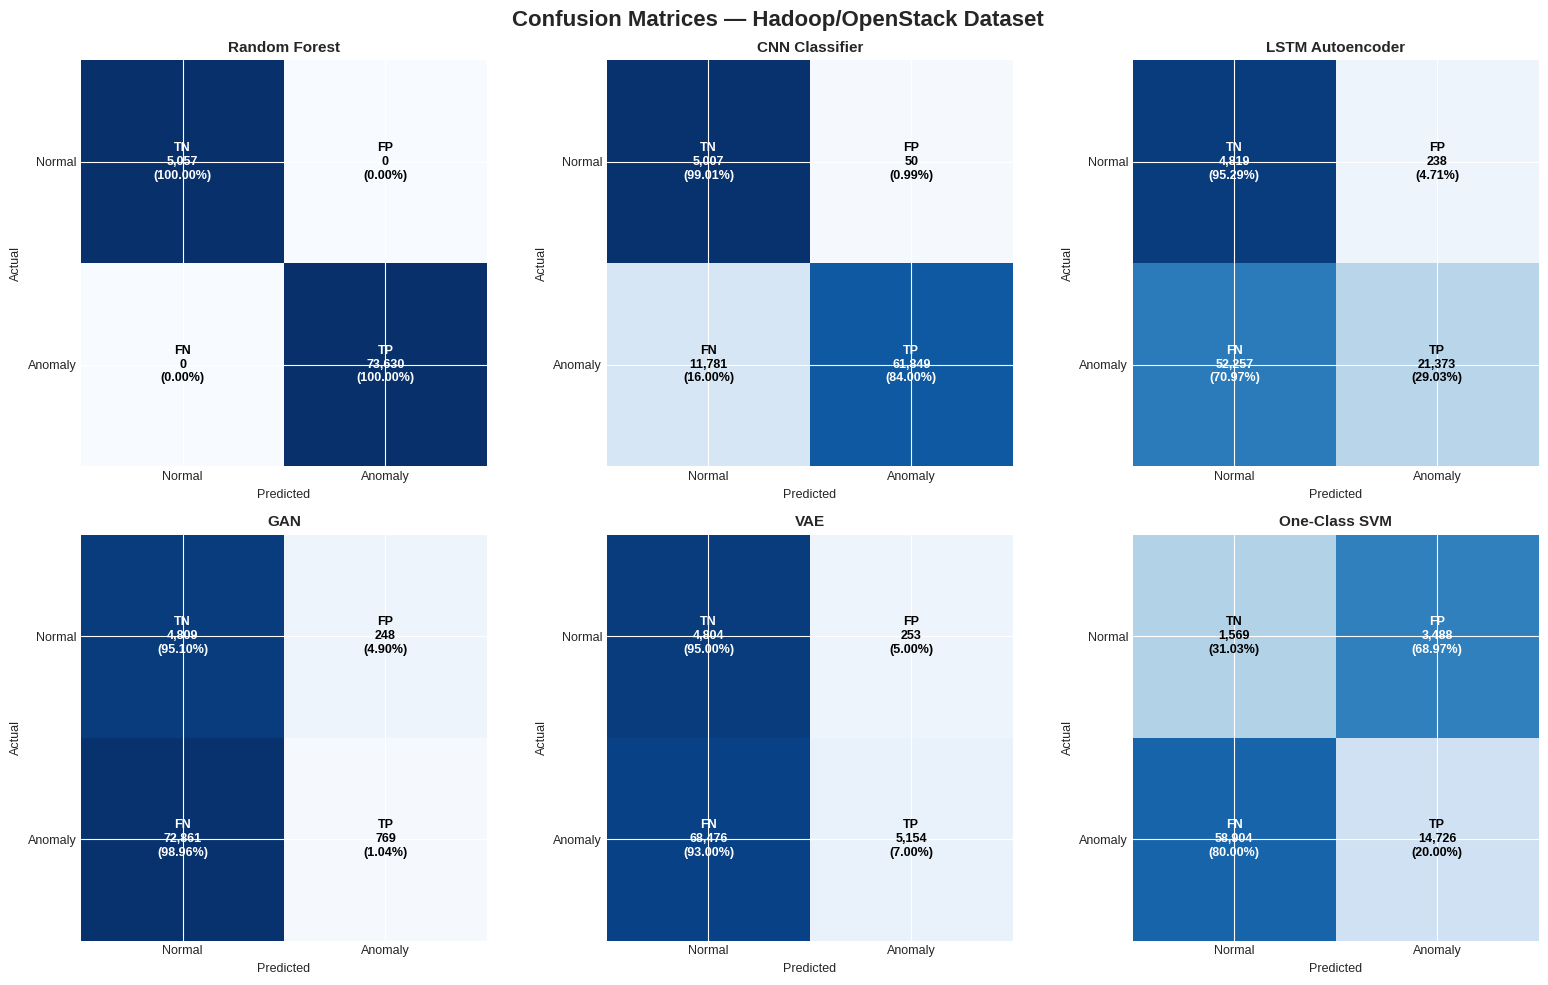

Figure 6 saved! ✅


/tmp/ipykernel_1566/186495282.py:109: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1566/186495282.py:109: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1566/186495282.py:110: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Liberation Sans.
  plt.savefig(f"{save_dir}/final_summary_both_datasets.png",
/tmp/ipykernel_1566/186495282.py:110: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  plt.savefig(f"{save_dir}/final_summary_both_datasets.png",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing fro

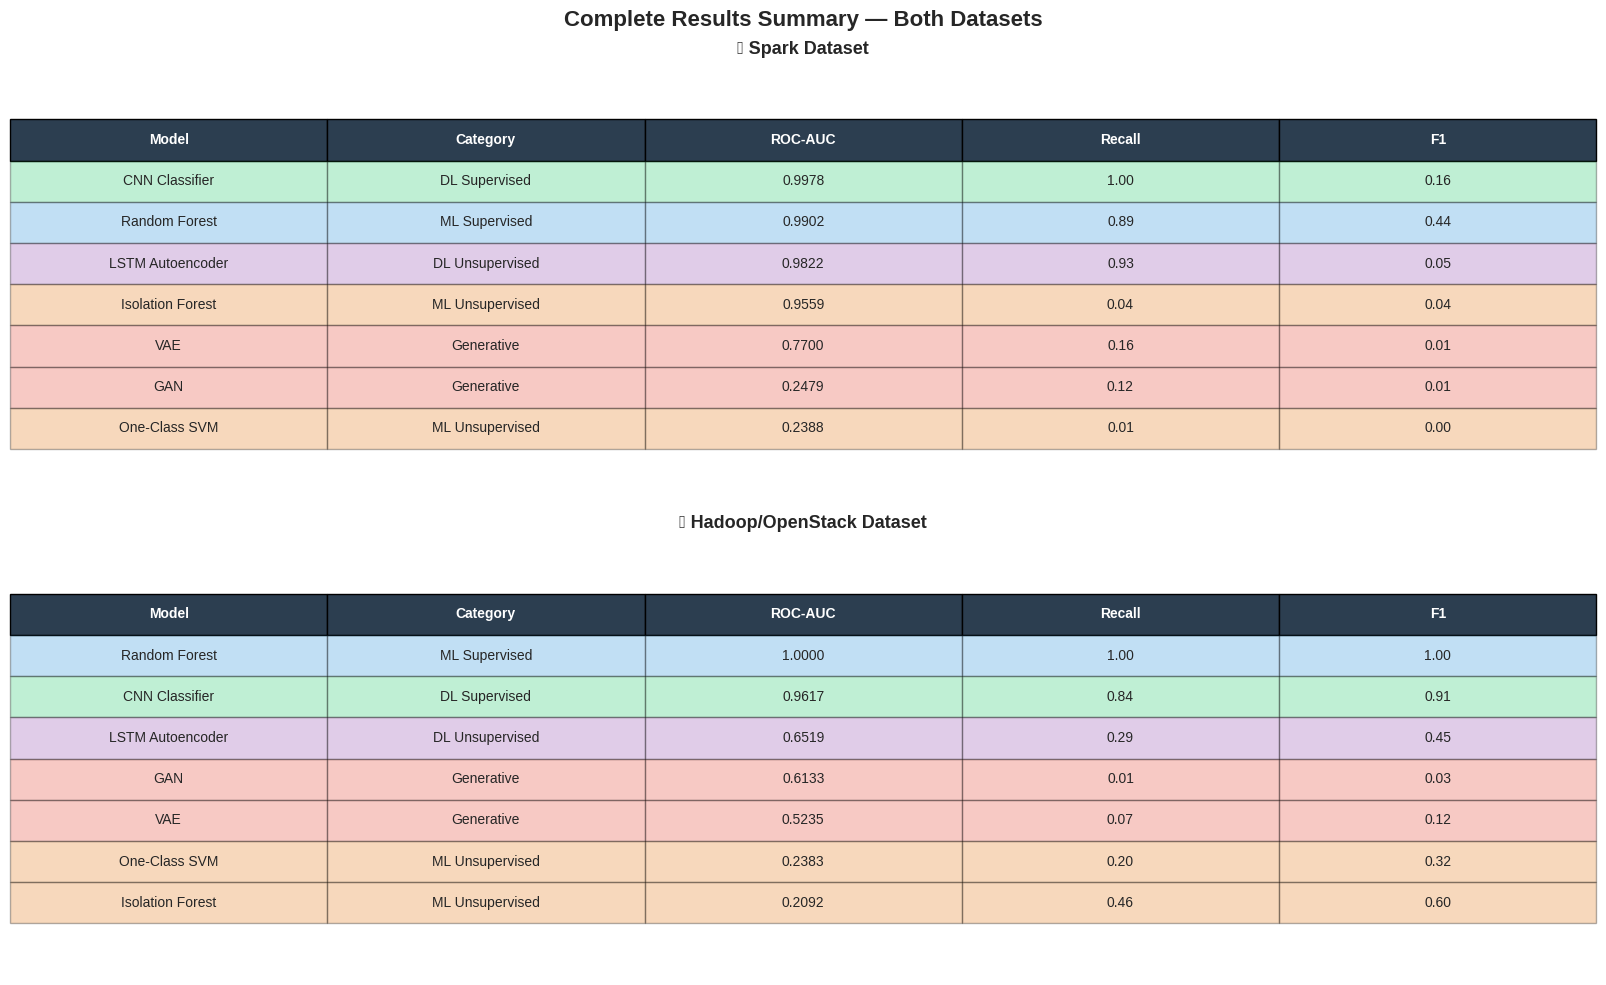

Figure 7 saved! ✅

✅ Sab graphs complete!
Total figures: 7
Saved at: /content/drive/MyDrive/hadoop_openstack


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================
# FIGURE 6: Hadoop Confusion Matrices
# ============================================
fig6, axes = plt.subplots(2, 3, figsize=(16, 10))
fig6.suptitle("Confusion Matrices — Hadoop/OpenStack Dataset",
              fontsize=16, fontweight='bold')

cms_hadoop = {
    "Random Forest":    np.array([[5057, 0],      [0, 73630]]),
    "CNN Classifier":   np.array([[5007, 50],     [11781, 61849]]),
    "LSTM Autoencoder": np.array([[4819, 238],    [52257, 21373]]),
    "GAN":              np.array([[4809, 248],    [72861, 769]]),
    "VAE":              np.array([[4804, 253],    [68476, 5154]]),
    "One-Class SVM":    np.array([[1569, 3488],   [58904, 14726]]),
}

for ax, (model_name, cm) in zip(axes.flatten(), cms_hadoop.items()):
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    im = ax.imshow(cm_norm, interpolation='nearest',
                   cmap='Blues', vmin=0, vmax=1)
    ax.set_title(model_name, fontsize=11, fontweight='bold')

    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{labels[i][j]}\n{cm[i,j]:,}\n({cm_norm[i,j]:.2%})',
                   ha='center', va='center', fontsize=9,
                   color='white' if cm_norm[i,j] > 0.5 else 'black',
                   fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Anomaly'], fontsize=9)
    ax.set_yticklabels(['Normal', 'Anomaly'], fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)

plt.tight_layout()
plt.savefig(f"{save_dir}/hadoop_confusion_matrices.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 saved! ✅")

# ============================================
# FIGURE 7: Final Summary Table Image
# ============================================
fig7, axes7 = plt.subplots(2, 1, figsize=(16, 10))
fig7.suptitle("Complete Results Summary — Both Datasets",
              fontsize=16, fontweight='bold')

# Spark table
spark_data = [
    ["CNN Classifier",   "DL Supervised",   "0.9978", "1.00", "0.16"],
    ["Random Forest",    "ML Supervised",   "0.9902", "0.89", "0.44"],
    ["LSTM Autoencoder", "DL Unsupervised", "0.9822", "0.93", "0.05"],
    ["Isolation Forest", "ML Unsupervised", "0.9559", "0.04", "0.04"],
    ["VAE",              "Generative",      "0.7700", "0.16", "0.01"],
    ["GAN",              "Generative",      "0.2479", "0.12", "0.01"],
    ["One-Class SVM",    "ML Unsupervised", "0.2388", "0.01", "0.00"],
]

hadoop_data = [
    ["Random Forest",    "ML Supervised",   "1.0000", "1.00", "1.00"],
    ["CNN Classifier",   "DL Supervised",   "0.9617", "0.84", "0.91"],
    ["LSTM Autoencoder", "DL Unsupervised", "0.6519", "0.29", "0.45"],
    ["GAN",              "Generative",      "0.6133", "0.01", "0.03"],
    ["VAE",              "Generative",      "0.5235", "0.07", "0.12"],
    ["One-Class SVM",    "ML Unsupervised", "0.2383", "0.20", "0.32"],
    ["Isolation Forest", "ML Unsupervised", "0.2092", "0.46", "0.60"],
]

col_labels = ['Model', 'Category', 'ROC-AUC', 'Recall', 'F1']

row_colors_map = {
    'DL Supervised':   '#2ecc71',
    'ML Supervised':   '#3498db',
    'DL Unsupervised': '#9b59b6',
    'ML Unsupervised': '#e67e22',
    'Generative':      '#e74c3c'
}

for ax, data, title in [(axes7[0], spark_data, '🔵 Spark Dataset'),
                         (axes7[1], hadoop_data, '🔴 Hadoop/OpenStack Dataset')]:
    ax.axis('off')
    table = ax.table(cellText=data, colLabels=col_labels,
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 2)

    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#2c3e50')
        table[0, j].set_text_props(color='white', fontweight='bold')

    for i, row in enumerate(data):
        cat = row[1]
        color = row_colors_map.get(cat, '#ffffff')
        for j in range(len(col_labels)):
            table[i+1, j].set_facecolor(color)
            table[i+1, j].set_alpha(0.3)

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig(f"{save_dir}/final_summary_both_datasets.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved! ✅")

print("\n✅ Sab graphs complete!")
print(f"Total figures: 7")
print(f"Saved at: {save_dir}")

In [4]:
import json, os

save_dir = "/content/drive/MyDrive/hadoop_openstack"

# Complete both datasets results
complete_results = {
    "Spark": {
        "CNN_Classifier":   {"ROC_AUC": 0.9978, "Recall": 1.00, "F1": 0.16},
        "Random_Forest":    {"ROC_AUC": 0.9902, "Recall": 0.89, "F1": 0.44},
        "LSTM_Autoencoder": {"ROC_AUC": 0.9822, "Recall": 0.93, "F1": 0.05},
        "Isolation_Forest": {"ROC_AUC": 0.9559, "Recall": 0.04, "F1": 0.04},
        "VAE":              {"ROC_AUC": 0.7700, "Recall": 0.16, "F1": 0.01},
        "GAN":              {"ROC_AUC": 0.2479, "Recall": 0.12, "F1": 0.01},
        "OneClass_SVM":     {"ROC_AUC": 0.2388, "Recall": 0.01, "F1": 0.00},
    },
    "Hadoop": {
        "Random_Forest":    {"ROC_AUC": 1.0000, "Recall": 1.00, "F1": 1.00},
        "CNN_Classifier":   {"ROC_AUC": 0.9617, "Recall": 0.84, "F1": 0.91},
        "LSTM_Autoencoder": {"ROC_AUC": 0.6519, "Recall": 0.29, "F1": 0.45},
        "GAN":              {"ROC_AUC": 0.6133, "Recall": 0.01, "F1": 0.03},
        "VAE":              {"ROC_AUC": 0.5235, "Recall": 0.07, "F1": 0.12},
        "OneClass_SVM":     {"ROC_AUC": 0.2383, "Recall": 0.20, "F1": 0.32},
        "Isolation_Forest": {"ROC_AUC": 0.2092, "Recall": 0.46, "F1": 0.60},
    }
}

with open(f"{save_dir}/complete_both_datasets_results.json", "w") as f:
    json.dump(complete_results, f, indent=4)

print("Complete results saved! ✅")

# All saved files list
print("\nSaved files in Drive:")
for f in os.listdir(save_dir):
    size = os.path.getsize(f"{save_dir}/{f}") / 1024
    print(f"  {f} ({size:.1f} KB)")

Complete results saved! ✅

Saved files in Drive:
  Hadoop.zip (3336.3 KB)
  OpenStack (4.0 KB)
  hadoop_logs_parsed.csv (107984.1 KB)
  hadoop_traditional_ml_results.json (0.3 KB)
  hadoop_dl_results.json (0.2 KB)
  hadoop_generative_results.json (0.2 KB)
  hadoop_overview.png (177.0 KB)
  spark_vs_hadoop_comparison.png (78.2 KB)
  performance_heatmap.png (99.8 KB)
  category_comparison.png (82.9 KB)
  radar_chart.png (282.9 KB)
  hadoop_confusion_matrices.png (158.8 KB)
  final_summary_both_datasets.png (177.4 KB)
  complete_both_datasets_results.json (1.6 KB)


In [5]:
import subprocess

# Clone karo
result = subprocess.run(
    ['git', 'clone', 'https://github.com/asadkhanofficial2341-beep/ASAD-thesis-files.git'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

# Structure dekho
import os

print("\n=== REPO STRUCTURE ===")
for root, dirs, files in os.walk('/content/ASAD-thesis-files'):
    # Hidden folders skip karo
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    level = root.replace('/content/ASAD-thesis-files', '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = '  ' * (level + 1)
    for file in files:
        print(f"{subindent}{file}")


Cloning into 'ASAD-thesis-files'...


=== REPO STRUCTURE ===
ASAD-thesis-files/
  .gitattributes
  data/
    raw/
      spark/
        spark logs link.txt
      hadoop_openstack/
        Hadoop.zip
        OpenStack/
          openstack_abnormal.log
          openstack_normal2.log
          anomaly_labels.txt
          openstack_normal1.log
  notebooks/
    03_deep_learning.ipynb
    01_data_preprocessing.ipynb
    02_traditional_ml.ipynb
    05_comparative_analysis.ipynb
    04_generative_ai.ipynb
  docs/
    Asad 243260 MSAI-3 fall2024 Thesis Proposal 07012026.docx
    final thesis report asad msai 4 4-6-2026.docx
    asad ml thesis results.docx
  results/
    final_summary.csv
    complete_comparison.png
    all_results.json
    complete_results.json
    traditional_ml_results.json
    confusion_matrices.png
    final_summary_table.png


In [6]:
import os
import shutil

repo = '/content/ASAD-thesis-files'

# ============================================
# Step 1: Folders banao
# ============================================
os.makedirs(f"{repo}/notebooks/spark", exist_ok=True)
os.makedirs(f"{repo}/notebooks/hadoop", exist_ok=True)
os.makedirs(f"{repo}/results/spark", exist_ok=True)
os.makedirs(f"{repo}/results/hadoop", exist_ok=True)
print("Folders created! ✅")

# ============================================
# Step 2: Spark notebooks move karo
# ============================================
spark_notebooks = [
    '01_data_preprocessing.ipynb',
    '02_traditional_ml.ipynb',
    '03_deep_learning.ipynb',
    '04_generative_ai.ipynb',
    '05_comparative_analysis.ipynb'
]

for nb in spark_notebooks:
    src = f"{repo}/notebooks/{nb}"
    dst = f"{repo}/notebooks/spark/{nb}"
    if os.path.exists(src):
        shutil.move(src, dst)
        print(f"Moved: {nb} → spark/")

# ============================================
# Step 3: Spark results move karo
# ============================================
spark_results = [
    'final_summary.csv',
    'complete_comparison.png',
    'all_results.json',
    'complete_results.json',
    'traditional_ml_results.json',
    'confusion_matrices.png',
    'final_summary_table.png'
]

for f in spark_results:
    src = f"{repo}/results/{f}"
    dst = f"{repo}/results/spark/{f}"
    if os.path.exists(src):
        shutil.move(src, dst)
        print(f"Moved: {f} → results/spark/")

print("\nSpark files organized! ✅")

# ============================================
# Step 4: Hadoop notebooks Drive se copy karo
# ============================================
hadoop_notebooks_src = "/content/drive/MyDrive/hadoop_openstack"
hadoop_notebooks = [
    '01_data_preprocessing_hadoop.ipynb',
    '02_traditional_ml_hadoop.ipynb',
    '03_deep_learning_hadoop.ipynb',
    '04_generative_ai_hadoop.ipynb',
    '05_comparative_analysis_hadoop.ipynb'
]

for nb in hadoop_notebooks:
    src = f"{hadoop_notebooks_src}/{nb}"
    dst = f"{repo}/notebooks/hadoop/{nb}"
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"Copied: {nb} → hadoop/")
    else:
        print(f"NOT FOUND: {nb} — manually add karna hoga")

# ============================================
# Step 5: Hadoop results Drive se copy karo
# ============================================
hadoop_results_files = [
    'hadoop_overview.png',
    'spark_vs_hadoop_comparison.png',
    'performance_heatmap.png',
    'category_comparison.png',
    'radar_chart.png',
    'hadoop_confusion_matrices.png',
    'final_summary_both_datasets.png',
    'complete_both_datasets_results.json',
    'hadoop_traditional_ml_results.json',
    'hadoop_dl_results.json',
    'hadoop_generative_results.json',
]

for f in hadoop_results_files:
    src = f"{hadoop_notebooks_src}/{f}"
    dst = f"{repo}/results/hadoop/{f}"
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"Copied: {f} → results/hadoop/")
    else:
        print(f"NOT FOUND: {f}")

print("\nHadoop files organized! ✅")

# ============================================
# Step 6: Final structure dekho
# ============================================
print("\n=== NEW REPO STRUCTURE ===")
for root, dirs, files in os.walk(repo):
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    level = root.replace(repo, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = '  ' * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

Folders created! ✅
Moved: 01_data_preprocessing.ipynb → spark/
Moved: 02_traditional_ml.ipynb → spark/
Moved: 03_deep_learning.ipynb → spark/
Moved: 04_generative_ai.ipynb → spark/
Moved: 05_comparative_analysis.ipynb → spark/
Moved: final_summary.csv → results/spark/
Moved: complete_comparison.png → results/spark/
Moved: all_results.json → results/spark/
Moved: complete_results.json → results/spark/
Moved: traditional_ml_results.json → results/spark/
Moved: confusion_matrices.png → results/spark/
Moved: final_summary_table.png → results/spark/

Spark files organized! ✅
NOT FOUND: 01_data_preprocessing_hadoop.ipynb — manually add karna hoga
NOT FOUND: 02_traditional_ml_hadoop.ipynb — manually add karna hoga
NOT FOUND: 03_deep_learning_hadoop.ipynb — manually add karna hoga
NOT FOUND: 04_generative_ai_hadoop.ipynb — manually add karna hoga
NOT FOUND: 05_comparative_analysis_hadoop.ipynb — manually add karna hoga
Copied: hadoop_overview.png → results/hadoop/
Copied: spark_vs_hadoop_compa

In [7]:
import shutil
import os

# School Drive pe folder banao
os.makedirs("/content/drive/MyDrive/ASAD_Thesis_Hadoop/notebooks", exist_ok=True)
os.makedirs("/content/drive/MyDrive/ASAD_Thesis_Hadoop/results", exist_ok=True)
print("Folders created! ✅")

# ============================================
# Notebooks copy karo
# ============================================
# Colab notebooks ka default path
colab_path = "/content/drive/MyDrive/Colab Notebooks"

hadoop_notebooks = [
    '01_data_preprocessing_hadoop.ipynb',
    '02_traditional_ml_hadoop.ipynb',
    '03_deep_learning_hadoop.ipynb',
    '04_generative_ai_hadoop.ipynb',
    '05_comparative_analysis_hadoop.ipynb'
]

for nb in hadoop_notebooks:
    src = f"{colab_path}/{nb}"
    dst = f"/content/drive/MyDrive/ASAD_Thesis_Hadoop/notebooks/{nb}"
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"Copied: {nb} ✅")
    else:
        print(f"NOT FOUND: {nb} ❌ — path check karo")

# ============================================
# Results copy karo
# ============================================
hadoop_results = [
    'hadoop_overview.png',
    'spark_vs_hadoop_comparison.png',
    'performance_heatmap.png',
    'category_comparison.png',
    'radar_chart.png',
    'hadoop_confusion_matrices.png',
    'final_summary_both_datasets.png',
    'complete_both_datasets_results.json',
    'hadoop_traditional_ml_results.json',
    'hadoop_dl_results.json',
    'hadoop_generative_results.json',
]

for f in hadoop_results:
    src = f"/content/drive/MyDrive/hadoop_openstack/{f}"
    dst = f"/content/drive/MyDrive/ASAD_Thesis_Hadoop/results/{f}"
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"Copied: {f} ✅")
    else:
        print(f"NOT FOUND: {f} ❌")

print("\nDone! Check karo Drive pe ASAD_Thesis_Hadoop folder! ✅")

Folders created! ✅
Copied: 01_data_preprocessing_hadoop.ipynb ✅
Copied: 02_traditional_ml_hadoop.ipynb ✅
NOT FOUND: 03_deep_learning_hadoop.ipynb ❌ — path check karo
Copied: 04_generative_ai_hadoop.ipynb ✅
NOT FOUND: 05_comparative_analysis_hadoop.ipynb ❌ — path check karo
Copied: hadoop_overview.png ✅
Copied: spark_vs_hadoop_comparison.png ✅
Copied: performance_heatmap.png ✅
Copied: category_comparison.png ✅
Copied: radar_chart.png ✅
Copied: hadoop_confusion_matrices.png ✅
Copied: final_summary_both_datasets.png ✅
Copied: complete_both_datasets_results.json ✅
Copied: hadoop_traditional_ml_results.json ✅
Copied: hadoop_dl_results.json ✅
Copied: hadoop_generative_results.json ✅

Done! Check karo Drive pe ASAD_Thesis_Hadoop folder! ✅


In [8]:
import shutil
import os

repo = '/content/ASAD-thesis-files'

# ============================================
# Step 1: Folders banao
# ============================================
os.makedirs(f"{repo}/notebooks/hadoop", exist_ok=True)
os.makedirs(f"{repo}/notebooks/spark", exist_ok=True)
os.makedirs(f"{repo}/results/hadoop", exist_ok=True)
os.makedirs(f"{repo}/results/spark", exist_ok=True)
print("Folders created! ✅")

# ============================================
# Step 2: Hadoop Notebooks — Drive se Git mein
# ============================================
hadoop_nb_src = "/content/drive/MyDrive/ASAD_Thesis_Hadoop/notebooks"
hadoop_notebooks = [
    '01_data_preprocessing_hadoop.ipynb',
    '02_traditional_ml_hadoop.ipynb',
    '03_deep_learning_hadoop.ipynb',
    '04_generative_ai_hadoop.ipynb',
    '05_comparative_analysis_hadoop.ipynb'
]

print("\nHadoop notebooks copy ho rahe hain...")
for nb in hadoop_notebooks:
    src = f"{hadoop_nb_src}/{nb}"
    dst = f"{repo}/notebooks/hadoop/{nb}"
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"✅ {nb}")
    else:
        print(f"❌ NOT FOUND: {nb}")

# ============================================
# Step 3: Spark Notebooks — Already hain repo mein
# Sirf check karo
# ============================================
print("\nSpark notebooks check...")
spark_notebooks = [
    '01_data_preprocessing.ipynb',
    '02_traditional_ml.ipynb',
    '03_deep_learning.ipynb',
    '04_generative_ai.ipynb',
    '05_comparative_analysis.ipynb'
]

for nb in spark_notebooks:
    path = f"{repo}/notebooks/spark/{nb}"
    if os.path.exists(path):
        print(f"✅ {nb} — already hai")
    else:
        print(f"❌ {nb} — missing!")

# ============================================
# Step 4: Hadoop Results — Drive se Git mein
# ============================================
hadoop_results_src = "/content/drive/MyDrive/ASAD_Thesis_Hadoop/results"
hadoop_results = [
    'hadoop_overview.png',
    'spark_vs_hadoop_comparison.png',
    'performance_heatmap.png',
    'category_comparison.png',
    'radar_chart.png',
    'hadoop_confusion_matrices.png',
    'final_summary_both_datasets.png',
    'complete_both_datasets_results.json',
    'hadoop_traditional_ml_results.json',
    'hadoop_dl_results.json',
    'hadoop_generative_results.json',
]

print("\nHadoop results copy ho rahe hain...")
for f in hadoop_results:
    src = f"{hadoop_results_src}/{f}"
    dst = f"{repo}/results/hadoop/{f}"
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"✅ {f}")
    else:
        print(f"❌ NOT FOUND: {f}")

# ============================================
# Step 5: Spark Results — Already hain repo mein
# Sirf check karo
# ============================================
print("\nSpark results check...")
spark_results = [
    'final_summary.csv',
    'complete_comparison.png',
    'all_results.json',
    'complete_results.json',
    'traditional_ml_results.json',
    'confusion_matrices.png',
    'final_summary_table.png'
]

for f in spark_results:
    path = f"{repo}/results/spark/{f}"
    if os.path.exists(path):
        print(f"✅ {f} — already hai")
    else:
        print(f"❌ {f} — missing!")

# ============================================
# Step 6: Final Structure
# ============================================
print("\n=== FINAL REPO STRUCTURE ===")
for root, dirs, files in os.walk(repo):
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    level = root.replace(repo, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = '  ' * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

Folders created! ✅

Hadoop notebooks copy ho rahe hain...
✅ 01_data_preprocessing_hadoop.ipynb
✅ 02_traditional_ml_hadoop.ipynb
❌ NOT FOUND: 03_deep_learning_hadoop.ipynb
✅ 04_generative_ai_hadoop.ipynb
❌ NOT FOUND: 05_comparative_analysis_hadoop.ipynb

Spark notebooks check...
✅ 01_data_preprocessing.ipynb — already hai
✅ 02_traditional_ml.ipynb — already hai
✅ 03_deep_learning.ipynb — already hai
✅ 04_generative_ai.ipynb — already hai
✅ 05_comparative_analysis.ipynb — already hai

Hadoop results copy ho rahe hain...
✅ hadoop_overview.png
✅ spark_vs_hadoop_comparison.png
✅ performance_heatmap.png
✅ category_comparison.png
✅ radar_chart.png
✅ hadoop_confusion_matrices.png
✅ final_summary_both_datasets.png
✅ complete_both_datasets_results.json
✅ hadoop_traditional_ml_results.json
✅ hadoop_dl_results.json
✅ hadoop_generative_results.json

Spark results check...
✅ final_summary.csv — already hai
✅ complete_comparison.png — already hai
✅ all_results.json — already hai
✅ complete_results.js

In [9]:
import os
print(os.listdir("/content/drive/MyDrive/ASAD_Thesis_Hadoop/notebooks"))

['03_deep_learning_hadoop.ipynb.ipynb', ' 05_comparative_analysis_hadoop.ipynb', '01_data_preprocessing_hadoop.ipynb', '02_traditional_ml_hadoop.ipynb', '04_generative_ai_hadoop.ipynb']
